In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv, DataFrame
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [2]:
df = pd.read_csv('./train.csv')

In [3]:
df.head(20)

,new_id,Месяц,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,1,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,22041969.33
1,0,2,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23268490.57
2,0,3,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,24487732.21
3,0,4,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23981980.29
4,0,5,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,26608343.78
5,0,6,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,26148681.55
6,0,7,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,27292985.79
7,0,8,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,27712633.36
8,0,9,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,24366310.39
9,0,10,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,27145282.92


In [4]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 206150 entries, 0 to 206149
Data columns (total 19 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     206150 non-null  int64  
 1   Месяц                                      206150 non-null  int64  
 2   Дата открытия, категориальный              206150 non-null  str    
 3   Торговая площадь, категориальный           206150 non-null  str    
 4   Населенный пункт                           206150 non-null  str    
 5   Регион                                     206150 non-null  str    
 6   Численность населения                      206150 non-null  int64  
 7   Количество домохозяйств                    206150 non-null  int64  
 8   Трафик пеший, в час                        206150 non-null  int64  
 9   Трафик авто, в час                         206150 non-null  int64  
 10  Маркетплейсы, доста

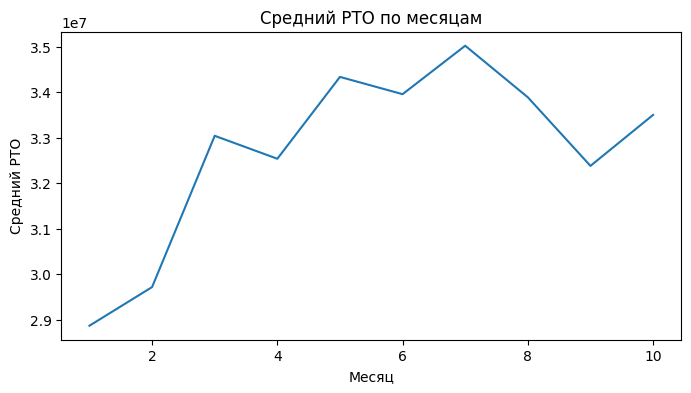

In [5]:
mean_rto_by_month = df.groupby("Месяц")["РТО"].mean()

plt.figure(figsize=(8, 4))
plt.plot(mean_rto_by_month.index, mean_rto_by_month.values)
plt.xlabel("Месяц")
plt.ylabel("Средний РТО")
plt.title("Средний РТО по месяцам")
plt.show()

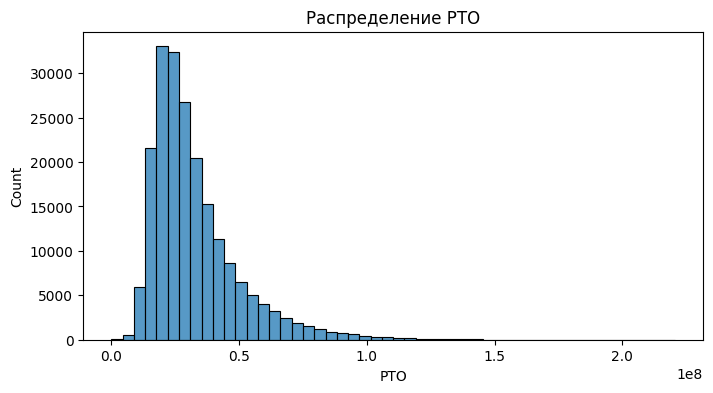

count    2.061500e+05
mean     3.272725e+07
std      1.768909e+07
min      1.619487e+04
25%      2.086432e+07
50%      2.791845e+07
75%      3.923328e+07
max      2.205870e+08
Name: РТО, dtype: float64


In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df["РТО"], bins=50)
plt.xlabel("РТО")
plt.title("Распределение РТО")
plt.show()
print(df["РТО"].describe())

Здесь: по оси х стандартное отклонение, конркетно здесь оно перекошено в правую сторону, что означает что больше половины магазинов зарабатывают меньше среднего значения, более того искодя из std, максимума и среднего значения видно, что здесь есть очень большие выбросы, так как включены крупные гипермаркеты в крупных городах, а также, исходя из значения min - в датасет включены только что открывшиеся по видимому магазины - > из-за выбросов модель модет быть неустойчива

In [7]:
from scipy import stats

это немножечко эксперимента с трансформацией данных

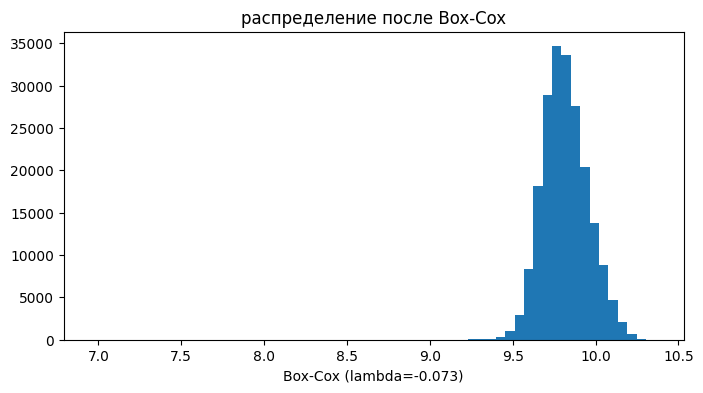

count    206150.000000
mean          9.817314
std           0.136949
min           6.959735
25%           9.723331
50%           9.808138
75%           9.904966
max          10.361162
dtype: float64
Skew: -0.03208318033200775


In [8]:
x = df["РТО"]

x = df["РТО"].values

x_boxcox, lam = stats.boxcox(x)

plt.figure(figsize=(8, 4))
plt.hist(x_boxcox, bins=60)

plt.xlabel(f"Box-Cox (lambda={lam:.3f})")
plt.title("распределение после Box-Cox")
plt.show()

print(pd.Series(x_boxcox).describe())
print("Skew:", pd.Series(x_boxcox).skew())

In [3]:
from statsmodels.stats.stattools import robust_kurtosis

короче здесь тоже немного анализа, которые подтверждает теория о больших выбросах

In [10]:
monthly = df.groupby('Месяц')['РТО'].agg(
    mean='mean',
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index()

print("\n" + "=" * 60)
print("СРЕДНЕЕ РТО ПО МЕСЯЦАМ")
print("=" * 60)
for i in range(len(monthly)):
    row = monthly.iloc[i]
    
    month = int(row['Месяц'])
    mean = row['mean'] / 1e6
    median = row['median'] / 1e6
    q1 = row["q25"] / 1e6
    q2 = row["q75"] / 1e6
    
    print("Месяц", month, ":", round(mean, 1), "M (медиана", round(median, 1), "M)", "Q25", q1,  "Q75", q2)




СРЕДНЕЕ РТО ПО МЕСЯЦАМ
Месяц 1 : 28.9 M (медиана 24.5 M) Q25 18.509860325 Q75 34.39518157
Месяц 2 : 29.7 M (медиана 25.1 M) Q25 18.89554874 Q75 35.404178205
Месяц 3 : 33.0 M (медиана 28.0 M) Q25 20.991348969999997 Q75 39.368165365
Месяц 4 : 32.5 M (медиана 27.8 M) Q25 20.8173447 Q75 38.929619595
Месяц 5 : 34.3 M (медиана 29.5 M) Q25 22.018486385 Q75 41.101012395
Месяц 6 : 34.0 M (медиана 29.2 M) Q25 21.68228259 Q75 40.990370094999996
Месяц 7 : 35.0 M (медиана 30.1 M) Q25 22.429105689999997 Q75 42.364905655
Месяц 8 : 33.9 M (медиана 29.2 M) Q25 21.718722575 Q75 40.932511334999994
Месяц 9 : 32.4 M (медиана 27.7 M) Q25 20.802698600000003 Q75 38.72300668
Месяц 10 : 33.5 M (медиана 28.7 M) Q25 21.571727700000004 Q75 39.84408974


Коэффициент вариации (CV) — статистический показатель, который измеряет разброс данных относительно среднего значения. Простыми словами, он показывает, данные «кучные» и предсказуемые или «разбросанные» и хаотичные - > показывает нестабильность относительно масштаба

IQR (Interquartile Range, межквартильный размах) — это статистическая мера разброса данных, которая показывает диапазон, в котором находятся центральные 50% наблюдений в наборе данных. Она рассчитывается как разность между третьим (Q3) и первым (Q1) квартилями

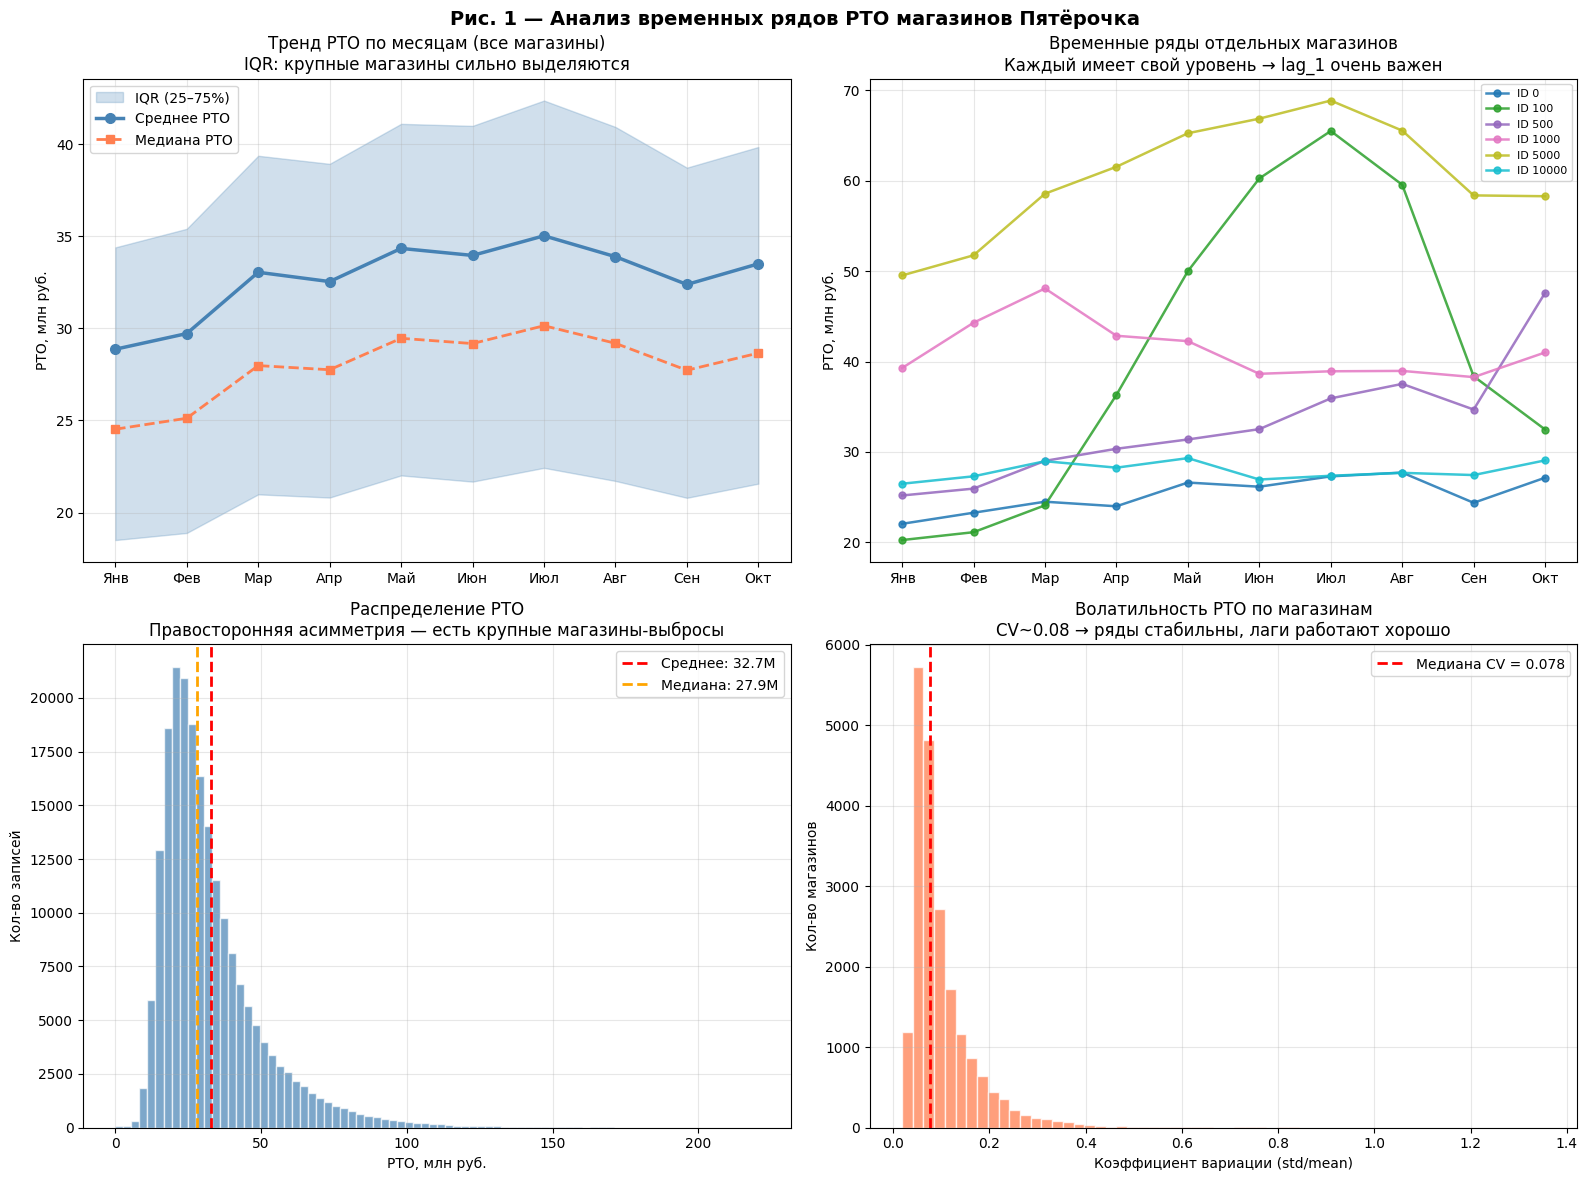

In [11]:
months = np.arange(1, 11)
MN = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт']

pivot = df.pivot(index='new_id', columns='Месяц', values='РТО') # строки - id, столбцы - месяц, знач в клетках - рто
# сред знач вычесляется по строкам (axis = 1 все делается по строкам, = 0 по столбцам)
# считаем коэфициент вариации
cv_stores = (pivot.std(axis=1) / pivot.mean(axis=1)).values

fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # строим сетку с 4 графиками
fig.suptitle('Рис. 1 — Анализ временных рядов РТО магазинов Пятёрочка', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.fill_between(monthly['Месяц'], 
                monthly['q25']/1e6, 
                monthly['q75']/1e6,
                alpha=0.25, 
                color='steelblue', 
                label='IQR (25–75%)')
ax.plot(monthly['Месяц'], monthly['mean']/1e6, 'o-', color='steelblue', lw=2.5, ms=7, label='Среднее РТО')
ax.plot(monthly['Месяц'], monthly['median']/1e6, 's--', color='coral', lw=2, ms=6, label='Медиана РТО')
ax.set_xticks(months)
ax.set_xticklabels(MN)
ax.set_ylabel('РТО, млн руб.')
ax.set_title('Тренд РТО по месяцам (все магазины)\nIQR: крупные магазины сильно выделяются')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0,1]
for sid, col in zip([0, 100, 500, 1000, 5000, 10000], plt.cm.tab10(np.linspace(0, 1, 6))):
    s = df[df['new_id'] == sid].sort_values('Месяц')
    ax.plot(s['Месяц'], s['РТО']/1e6, 'o-', color=col, lw=1.8, ms=5, alpha=0.85, label=f'ID {sid}')
ax.set_xticks(months); ax.set_xticklabels(MN); ax.set_ylabel('РТО, млн руб.')
ax.set_title('Временные ряды отдельных магазинов\nКаждый имеет свой уровень → lag_1 очень важен')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,0]
rto_vals = df['РТО'].values / 1e6
ax.hist(rto_vals, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(rto_vals), color='red', ls='--', lw=2, label=f'Среднее: {np.mean(rto_vals):.1f}M')
ax.axvline(np.median(rto_vals), color='orange', ls='--', lw=2, label=f'Медиана: {np.median(rto_vals):.1f}M')
ax.set_xlabel('РТО, млн руб.'); ax.set_ylabel('Кол-во записей')
ax.set_title('Распределение РТО\nПравосторонняя асимметрия — есть крупные магазины-выбросы')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1,1]
ax.hist(cv_stores, bins=60, color='coral', alpha=0.75, edgecolor='white')
ax.axvline(np.median(cv_stores), color='red', ls='--', lw=2, label=f'Медиана CV = {np.median(cv_stores):.3f}')
ax.set_xlabel('Коэффициент вариации (std/mean)'); ax.set_ylabel('Кол-во магазинов')
ax.set_title(f'Волатильность РТО по магазинам\nCV~{np.median(cv_stores):.2f} → ряды стабильны, лаги работают хорошо')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_trends.png', dpi=120, bbox_inches='tight')
plt.show()


Вообще из второго графика вывод - данные нестационарны и заависят от времени, нецикличны, но есть сезонность плюс минус, есть шум

Ниже - stl разложение

[convolution explanation](https://www.youtube.com/watch?v=KuXjwB4LzSA)

In [12]:
import numpy as np

a = np.array([1, 2, 3])
v = np.array([0, 1, 0.5])

# Режим 'full' (по умолчанию)
result_full = np.convolve(a, v, mode='full')
print(result_full)

# Режим 'same'
result_same = np.convolve(a, v, mode='same')
print(result_same)

# Режим 'valid'
result_valid = np.convolve(a, v, mode='valid')
print(result_valid)


[0.  1.  2.5 4.  1.5]
[1.  2.5 4. ]
[2.5]


Среднеквадратическое отклонение (среднеквадратичное отклонение, стандартное отклонение) — статистическая характеристика распределения случайной величины, показывающая среднюю степень разброса значений величины относительно математического ожидания.

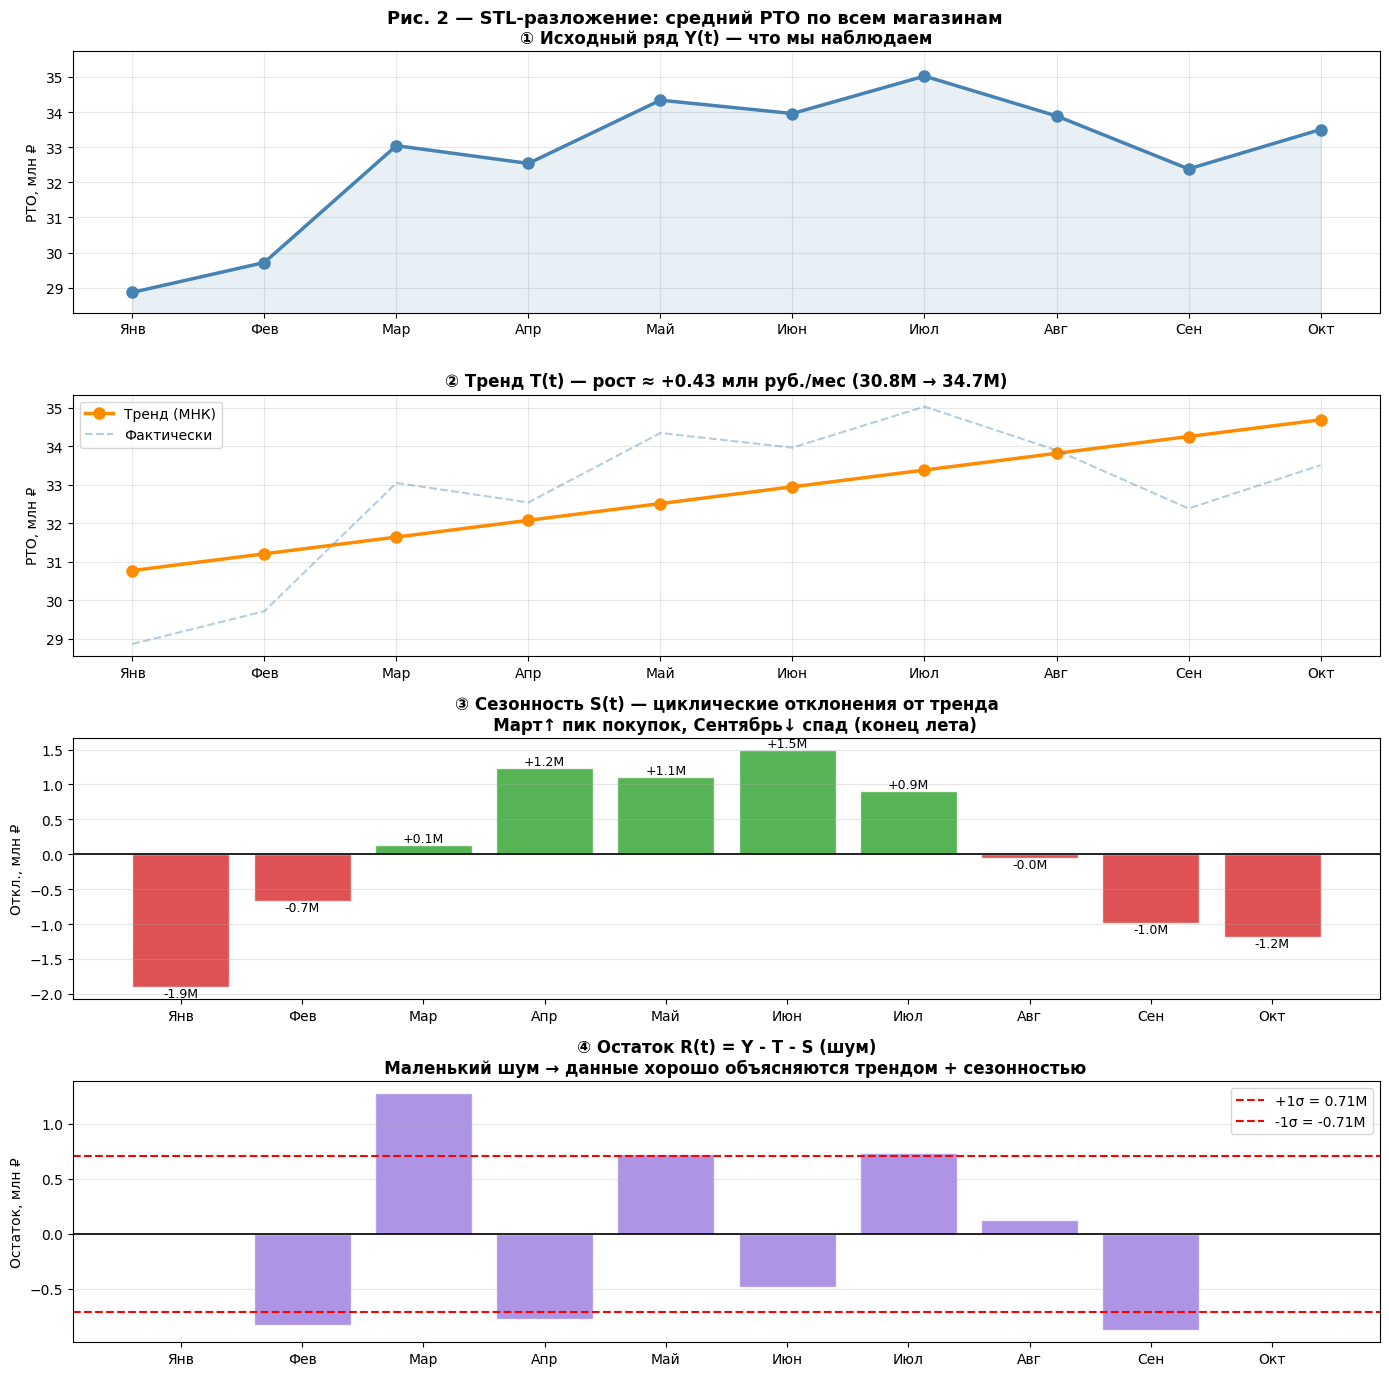

In [13]:
monthly_mean = df.groupby('Месяц')['РТО'].mean().values # таблица месяц и среднее значение РТО
trend_coef = np.polyfit(months, monthly_mean, 1)
trend = np.polyval(trend_coef, months) #линия тренда

# Сезонность = факт - тренд, сглаженная скользящим средним
detrended = monthly_mean - trend # сотается только сезонность и шум
def moving_avg(x, w=3): #скользящее среднее чтобы посмотреть сезонность
    r = np.convolve(x, np.ones(w)/w, mode='same') # "скользим" по значениям с окном в 3 (суммируем и делим на 3 каждое окно)
    r[0] = x[0] #костыль
    r[-1] = x[-1] #костыль
    return r
seasonal = moving_avg(detrended, w=3) #немного размытые данные
residual = monthly_mean - trend - seasonal #неизвестная часть модели, шум

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('Рис. 2 — STL-разложение: средний РТО по всем магазинам', fontsize=13, fontweight='bold')

axes[0].plot(months, monthly_mean/1e6, 'o-', color='steelblue', lw=2.5, ms=8)
axes[0].fill_between(months, monthly_mean/1e6, alpha=0.12, color='steelblue')
axes[0].set_title('① Исходный ряд Y(t) — что мы наблюдаем', fontweight='bold')
axes[0].set_ylabel('РТО, млн ₽')
axes[0].set_xticks(months)
axes[0].set_xticklabels(MN)
axes[0].set_ylim((monthly_mean / 1e6).min() * 0.98, (monthly_mean / 1e6).max() * 1.02)
axes[0].grid(alpha=0.3)

axes[1].plot(months, trend/1e6, 'o-', color='darkorange', lw=2.5, ms=8, label='Тренд (МНК)')
axes[1].plot(months, monthly_mean/1e6, '--', color='steelblue', lw=1.5, alpha=0.4, label='Фактически')
axes[1].set_title(f'② Тренд T(t) — рост ≈ +{trend_coef[0]/1e6:.2f} млн руб./мес '
                  f'({trend[0]/1e6:.1f}M → {trend[-1]/1e6:.1f}M)', fontweight='bold')
axes[1].set_ylabel('РТО, млн ₽')
axes[1].set_xticks(months)
axes[1].set_xticklabels(MN)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].bar(months, seasonal/1e6, color=['#2ca02c' if v>=0 else '#d62728' for v in seasonal],
            alpha=0.8, edgecolor='white')
axes[2].axhline(0, color='black', lw=1.2)
for m, v in zip(months, seasonal/1e6):
    axes[2].annotate(f'{v:+.1f}M', (m, v), ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
axes[2].set_title('③ Сезонность S(t) — циклические отклонения от тренда\n'
                  '   Март↑ пик покупок, Сентябрь↓ спад (конец лета)', fontweight='bold')
axes[2].set_ylabel('Откл., млн ₽'); axes[2].set_xticks(months)
axes[2].set_xticklabels(MN)
axes[2].grid(alpha=0.3, axis='y')

axes[3].bar(months, residual/1e6, color='mediumpurple', alpha=0.75, edgecolor='white')
axes[3].axhline(0, color='black', lw=1.2)
#standart deviation
axes[3].axhline(residual.std()/1e6, color='red', ls='--', lw=1.5, label=f'+1σ = {residual.std()/1e6:.2f}M')
axes[3].axhline(-residual.std()/1e6, color='red', ls='--', lw=1.5, label=f'-1σ = {-residual.std()/1e6:.2f}M')
axes[3].set_title('④ Остаток R(t) = Y - T - S (шум)\n'
                  '   Маленький шум → данные хорошо объясняются трендом + сезонностью', fontweight='bold')
axes[3].set_ylabel('Остаток, млн ₽'); axes[3].set_xticks(months)
axes[3].set_xticklabels(MN); axes[3].legend(); axes[3].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig2_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

Статичстические анализ

АКФ — Автокорреляционная функция:
  Показывает, насколько значение ряда в момент t коррелирует с t-lag.
  Высокая АКФ(1) → lag_1 будет отличным признаком модели.
  Если АКФ убывает медленно → ряд нестационарен (есть тренд).

## Гетероскедастичность (Heteroskedasticity)

Гетероскедастичность — это статистическое свойство данных, при котором дисперсия ошибок (остатков) в модели регрессии изменяется в зависимости от значений независимых переменных. Иными словами, разброс ошибок не является постоянным по всем наблюдениям. Это нарушает одно из ключевых предположений классической линейной регрессии и может привести к неэффективным оценкам и некорректным выводам.

### Ключевые факты

* **Тип явления:** Непостоянная дисперсия ошибок
* **Основное последствие:** Нарушение предположений модели ОЛС
* **Типичные тесты:** Тесты Бреуша–Пагана, Уайта
* **Методы коррекции:** Робастные стандартные ошибки, взвешенный МНК

### Причины возникновения

Гетероскедастичность часто возникает в данных, где масштаб наблюдений сильно различается: например, доходы компаний разного размера или потребление домохозяйств с разными доходами. В таких случаях изменчивость ошибок растёт вместе с уровнем объясняющей переменной.

### Влияние на оценку модели

При гетероскедастичности оценки коэффициентов методом наименьших квадратов остаются несмещёнными, но теряют эффективность: стандартные ошибки становятся неправильными, а статистические тесты — ненадёжными. Это может привести к неверной интерпретации значимости переменных.

### Диагностика

Для выявления гетероскедастичности используют графический анализ (остатки против предсказанных значений) и формальные тесты, такие как тест Бреуша–Пагана или тест Уайта. Они проверяют зависимость дисперсии ошибок от объясняющих переменных.

### Методы устранения

Среди распространённых подходов — использование робастных стандартных ошибок (например, по Уайту), логарифмирование переменных для стабилизации дисперсии и применение взвешенного метода наименьших квадратов (WLS), где каждому наблюдению присваивается вес, обратный его дисперсии.


In [4]:
from statsmodels.graphics.tsaplots import plot_acf

In [5]:
from statsmodels.tsa.stattools import adfuller

| p-value | вывод           |
| ------- | --------------- |
| < 0.05  | стационарен ✅   |
| > 0.05  | нестационарен ❌ |


NameError: name 'monthly_mean' is not defined

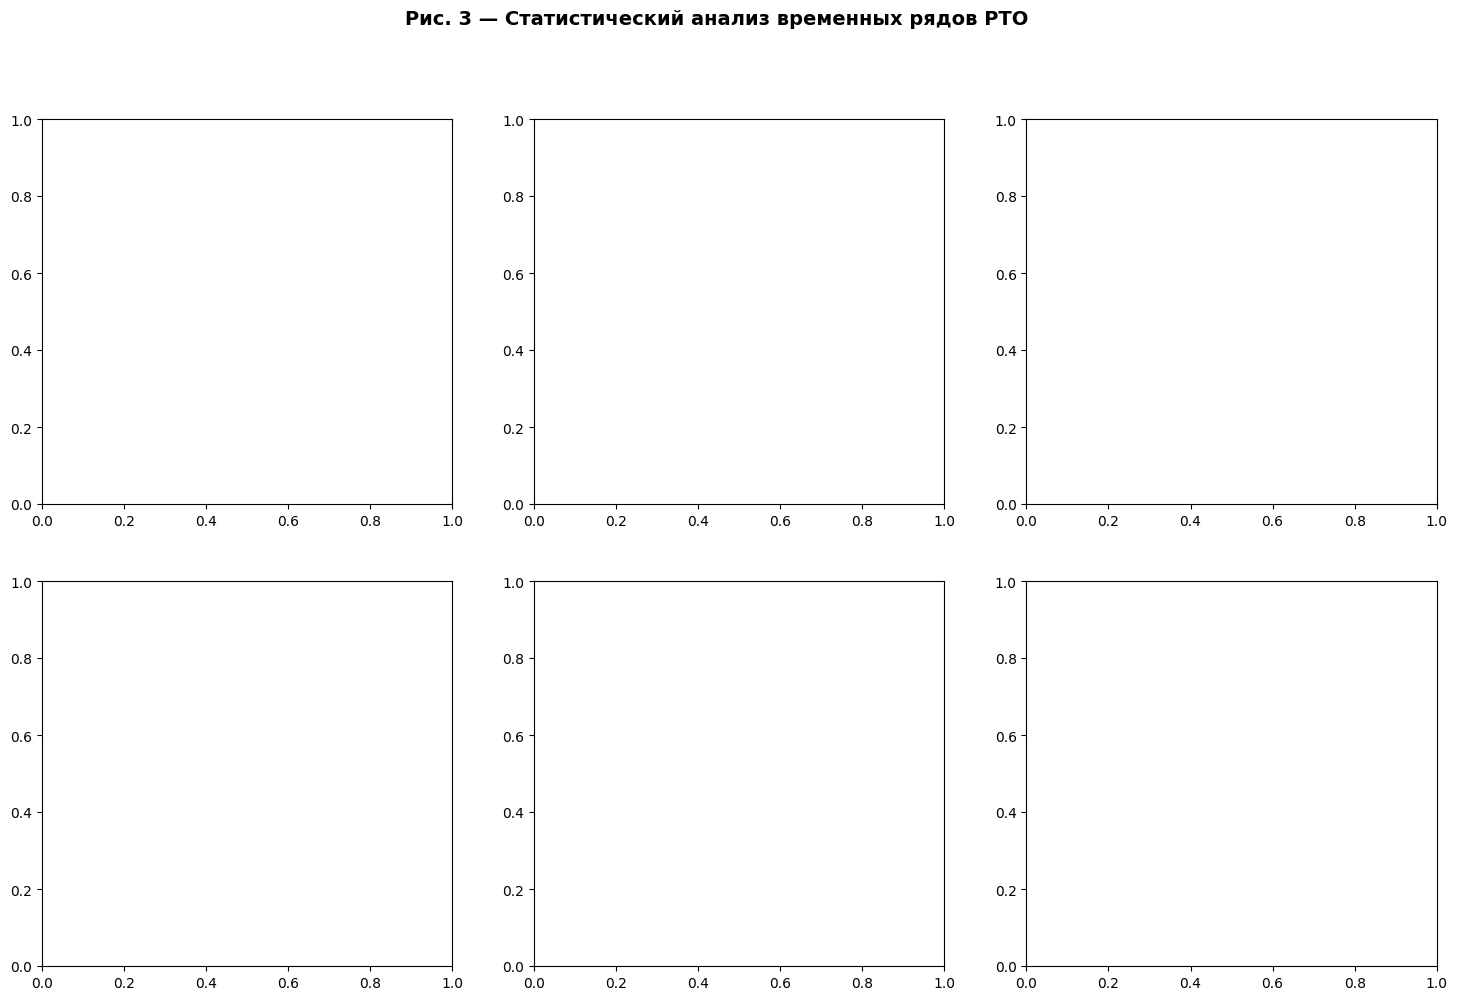

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Рис. 3 — Статистический анализ временных рядов РТО', fontsize=14, fontweight='bold')

# ACF
ax = axes[0,0]
plot_acf(monthly_mean, lags=9, ax=ax)
ax.set_title('АКФ среднего РТО')

# Скорость изменения (первые разности)
ax = axes[0,1]
diffs = np.diff(monthly_mean)
ax.bar(np.arange(2, 11), 
       diffs/1e6,
       color=['#2ca02c' if d>=0 else '#d62728' for d in diffs], 
       alpha=0.8, 
       edgecolor='white')
ax.axhline(0, color='black', lw=1.2)
for m, d in zip(np.arange(2, 11), diffs/1e6):
    ax.annotate(f'{d:+.1f}M', (m, d), ha='center', va='bottom' if d>=0 else 'top', fontsize=9)
ax.set_xticks(np.arange(2, 11))
ax.set_xticklabels(MN[1:])
ax.set_title('Скорость изменения: первые разности Δ(t)\n'
             'diff1 = RTO(t-1)-RTO(t-2) улавливает ускорение/торможение')
ax.set_ylabel('ΔРТО, млн ₽'); ax.grid(alpha=0.3, axis='y')

# Тест на стационарность
ax = axes[0,2]
rto_arr = pivot.values
sp_corrs = np.array([stats.spearmanr(range(10), rto_arr[i])[0] for i in range(len(rto_arr))])
ax.hist(sp_corrs, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.axvline(np.mean(sp_corrs), color='red', ls='--', lw=2, label=f'Среднее: {np.mean(sp_corrs):.3f}')
pup = (sp_corrs > 0.5).mean()*100; pdn = (sp_corrs < -0.5).mean()*100
ax.set_title(f'Стационарность (корреляция Спирмена РТО~Месяц)\n'
             f'↑ тренд {pup:.0f}%,  ↓ тренд {pdn:.0f}%,  без тренда {100-pup-pdn:.0f}%')
ax.set_xlabel('Корреляция Спирмена'); ax.legend(); ax.grid(alpha=0.3)

#какая то сложная херня, можно просто провести тест на стационарность через statsmodels

result = adfuller(monthly_mean)

print("ADF statistic:", result[0])
print("p-value:", result[1])

# Дисперсия по месяцам
ax = axes[1,0]
mstd = df.groupby('Месяц')['РТО'].std().values
mm   = df.groupby('Месяц')['РТО'].mean().values
ax.bar(months, mstd/1e6, color='mediumpurple', alpha=0.75, edgecolor='white', label='std РТО')
ax2 = ax.twinx() #делаем вторую ось y
ax2.plot(months, (mstd/mm)*100, 'o--', color='red', lw=2, label='CV, %')
ax.set_xticks(months)
ax.set_xticklabels(MN)
ax.set_ylabel('Стд. откл., млн ₽', color='mediumpurple')
ax2.set_ylabel('CV, %', color='red')
ax.set_title('Дисперсия РТО по месяцам\nCV почти одинаков → умеренная гетероскедастичность')
l1,lb1=ax.get_legend_handles_labels()
l2,lb2=ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9)
ax.grid(alpha=0.3)

# Корреляция экзогенных признаков с РТО
ax = axes[1,1]
num_cols = ['Численность населения','Количество домохозяйств','Трафик пеший, в час',
            'Трафик авто, в час','Маркетплейсы, доставки, постаматы (100 м)',
            'Медицинские уч. и аптеки (300 м)','Школы (300 м)','Остановки (300 м)',
            'Продуктовые магазины (500 м)','Пятерочки (500 м)','Количество касс','Флаг алкогольной лицензии']
corrs = df[num_cols + ['РТО']].corr()['РТО'].drop('РТО')
snames = ['Население','Домохозяйства','Пеш.трафик','Авт.трафик','Маркетпл.',
          'Медучр.','Школы','Остановки','Прод.маг.','Пятёрочки','Кол.касс','Алкоголь']
brs = ax.barh(snames, corrs.values,
              color=['steelblue' if c>=0 else 'coral' for c in corrs.values], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1.2)
for b, v in zip(brs, corrs.values):
    ax.text(v+(0.01 if v>=0 else -0.01), b.get_y()+b.get_height()/2,
            f'{v:.3f}', va='center', ha='left' if v>=0 else 'right', fontsize=8)
ax.set_xlabel('Корреляция Пирсона с РТО')
ax.set_title('Корреляция экзогенных признаков с РТО\n'
             'Кол-во касс (0.64) — лучший статический предиктор!'); ax.grid(alpha=0.3, axis='x')

# Волатильность по магазинам
ax = axes[1,2]
ax.hist(cv_stores, bins=60, color='coral', alpha=0.75, edgecolor='white')
ax.axvline(np.median(cv_stores), color='red', ls='--', lw=2, label=f'Медиана CV={np.median(cv_stores):.3f}')
ax.axvline(np.mean(cv_stores), color='darkred', ls='-', lw=1.5, label=f'Среднее CV={np.mean(cv_stores):.3f}')
ax.set_xlabel('Коэффициент вариации (std/mean)'); ax.set_ylabel('Кол-во магазинов')
ax.set_title(f'Волатильность по магазинам\nCV~{np.median(cv_stores):.2f}: ряды стабильны → лаги работают')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_stats.png', dpi=120, bbox_inches='tight')
plt.show()

из первого графика - данные нестационарны т.к. зависимость текущего значения от прошлых значений

🚀 итоговая картина

Твой ряд:

слабая зависимость от прошлого
нет сильной сезонности
нет сильной гетероскедастичности
возможен лёгкий тренд (ты его видела раньше)
💡 практический вывод (очень важный)

👉 сложные time-series модели (ARIMA и т.п.) не дадут большого выигрыша

лучше:
lag_1 как фича
diff (если есть тренд)
обычные ML модели

In [3]:
STATIC_FEATS = [
    'Дата открытия, категориальный',
    'Торговая площадь, категориальный',
    'Населенный пункт',
    'Регион',

    'Численность населения', 'Количество домохозяйств',
    'Трафик пеший, в час', 'Трафик авто, в час',
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)',
    'Остановки (300 м)', 'Продуктовые магазины (500 м)',
    'Пятерочки (500 м)', 'Количество касс',
    'Флаг алкогольной лицензии'
]

In [4]:
def build_features(data, target_month):
    """
    Feature engineering для прогноза месяца target_month.
    Используются только месяцы < target_month (без утечки).

    ВАЖНО:
    - предполагается, что дальше модель будет обучаться в log-space
    """

    # ========= 1. БАЗА =========
    months = list(range(1, target_month))
    cols = [f'rto_m{m}' for m in months]
    rto = data[cols].values  # shape (n_stores, n_months)

    n = rto.shape[0]

    # защита от нулей
    eps = 1e-9

    # ========= 2. ЛАГИ =========
    lag1 = data[f'rto_m{target_month-1}'].values
    lag2 = data[f'rto_m{target_month-2}'].values if target_month >= 3 else np.zeros(n)
    lag3 = data[f'rto_m{target_month-3}'].values if target_month >= 4 else np.zeros(n)

    # ========= 3. АГРЕГАТЫ =========
    ma3 = rto[:, -3:].mean(1) if rto.shape[1] >= 3 else rto.mean(1)
    ma6 = rto[:, -6:].mean(1) if rto.shape[1] >= 6 else rto.mean(1)
    ma_all = rto.mean(1)

    std_all = rto.std(1)
    cv = std_all / (ma_all + eps)

    min3 = rto[:, -3:].min(1) if rto.shape[1] >= 3 else rto.min(1)
    max3 = rto[:, -3:].max(1) if rto.shape[1] >= 3 else rto.max(1)
    range3 = max3 - min3

    # ========= 4. ДИНАМИКА =========
    if target_month >= 3:
        diff1 = lag1 - lag2
    else:
        diff1 = np.zeros(n)

    if target_month >= 4:
        diff2 = lag2 - lag3
    else:
        diff2 = np.zeros(n)

    acceleration = diff1 - diff2
    growth = diff1 / (np.abs(lag2) + eps)

    # ========= 5. ТРЕНД =========
    x = np.arange(rto.shape[1], dtype=float)
    x = x - x.mean()

    trend = (rto * x).sum(1) / ((x**2).sum() + eps)
    trend_norm = trend / (ma_all + eps)

    # локальный тренд (последние 3 месяца)
    if rto.shape[1] >= 3:
        local_weights = np.array([-1., 0., 1.])
        trend_last3 = (rto[:, -3:] * local_weights).sum(1)
    else:
        trend_last3 = np.zeros(n)

    # ========= 6. RELATIVE FEATURES =========
    lag1_to_mean = lag1 / (ma_all + eps)
    lag1_to_ma3 = lag1 / (ma3 + eps)

    ratio_last = lag1_to_mean  # алиас

    # ========= 7. НОРМАЛИЗАЦИЯ ПО МАГАЗИНУ =========
    lag1_centered = lag1 - ma_all
    lag1_scaled = lag1 / (std_all + eps)

    # ========= 8. LOG FEATURES =========
    lag1_log = np.log1p(lag1)
    ma3_log = np.log1p(ma3)
    ma_all_log = np.log1p(ma_all)

    # ========= 9. СЕЗОННОСТЬ =========
    month = target_month
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    # broadcast
    month_arr = np.full(n, month)
    sin_arr = np.full(n, month_sin)
    cos_arr = np.full(n, month_cos)

    # ========= 10. СБОРКА =========
    f = pd.DataFrame({
        # lag
        'lag1': lag1,
        'lag2': lag2,
        'lag3': lag3,

        # aggregates
        'ma3': ma3,
        'ma6': ma6,
        'ma_all': ma_all,
        'std_all': std_all,
        'cv': cv,
        'min3': min3,
        'max3': max3,
        'range3': range3,

        # dynamics
        'diff1': diff1,
        'diff2': diff2,
        'acceleration': acceleration,
        'growth': growth,

        # trend
        'trend': trend,
        'trend_norm': trend_norm,
        'trend_last3': trend_last3,

        # relative
        'lag1_to_mean': lag1_to_mean,
        'lag1_to_ma3': lag1_to_ma3,
        'ratio_last': ratio_last,

        # normalization
        'lag1_centered': lag1_centered,
        'lag1_scaled': lag1_scaled,

        # log features
        'lag1_log': lag1_log,
        'ma3_log': ma3_log,
        'ma_all_log': ma_all_log,

        # time
        'month': month_arr,
        'month_sin': sin_arr,
        'month_cos': cos_arr,
    }, index=data.index)

    # ========= 11. СТАТИКА =========
    for col in STATIC_FEATS:
        f[col] = data[col].values

    # ========= 12. ИНТЕРАКЦИИ (МИНИМАЛЬНО, НО СИЛЬНО) =========
    f['lag1_x_cass'] = lag1 * data['Количество касс'].values
    f['lag1_x_traffic'] = lag1 * data['Трафик пеший, в час'].values

    return f

In [5]:
"""
Walk-Forward Validation — стандарт для временных рядов:

    Train:   предсказываем месяцы 4–9 (история 1..target-1 для каждого)
    Test:    предсказываем месяц 10 (октябрь) — честная оценка качества
    Submit:  предсказываем месяц 11 (ноябрь) — финальный прогноз

Почему нельзя случайно перемешать 80/20?
    Временные ряды нельзя перемешивать! Если дать модели "будущее" при обучении
    → утечка данных → завышенные метрики → плохой результат на тесте.
"""

static_df = df[df['Месяц'] == 1][
    ['new_id', 'Дата открытия, категориальный', 'Торговая площадь, категориальный',
     'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств',
     'Трафик пеший, в час', 'Трафик авто, в час',
     'Маркетплейсы, доставки, постаматы (100 м)',
     'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)',
     'Продуктовые магазины (500 м)', 'Пятерочки (500 м)',
     'Количество касс', 'Флаг алкогольной лицензии']
].set_index('new_id')

pivot2 = df.pivot(index='new_id', columns='Месяц', values='РТО')
pivot2.columns = [f'rto_m{c}' for c in pivot2.columns]
data = static_df.join(pivot2)

# просто оставляем как есть (строки)
CAT_COLS = [
    'Дата открытия, категориальный',
    'Торговая площадь, категориальный',
    'Населенный пункт',
    'Регион'
]

COLS = list(build_features(data, 10).columns)  # канонический порядок признаков


In [6]:
import re

In [7]:
import lightgbm as lgb

print("\nWalk-forward CV...")

# фиксируем пространство признаков
def clean_cols(df):
    df = df.copy()
    df.columns = [re.sub(r'[^\w]', '_', col) for col in df.columns]
    return df

# Фиксируем чистое пространство признаков
ALL_FEATURES = clean_cols(
    pd.get_dummies(build_features(data, 10)[COLS])
).columns

mapes = []

for target_m in range(6, 11):
    X_tr_parts, y_tr_parts = [], []

    for m in range(4, target_m):
        X_tr_parts.append(build_features(data, m)[COLS])
        y_tr_parts.append(data[f'rto_m{m}'].values)

    X_tr = pd.concat(X_tr_parts)
    y_tr = np.concatenate(y_tr_parts)

    X_val = build_features(data, target_m)[COLS]
    y_val = data[f'rto_m{target_m}'].values

    # стабильные фичи
    X_tr = clean_cols(pd.get_dummies(X_tr)).reindex(columns=ALL_FEATURES, fill_value=0)
    X_val = clean_cols(pd.get_dummies(X_val)).reindex(columns=ALL_FEATURES, fill_value=0)

    # лог
    y_tr_log = np.log1p(y_tr)
    y_val_safe = np.where(y_val <= 0, 1e-6, y_val)

    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr_log,
        eval_set=[(X_val, np.log1p(y_val_safe))],
        eval_metric='l2',
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    pred = np.expm1(model.predict(X_val))
    pred = np.clip(pred, 0, np.percentile(y_tr, 99))

    mape = 100 * np.mean(np.abs((pred - y_val) / y_val_safe))
    mapes.append(mape)

    print(f"Месяц {target_m}: MAPE = {mape:.2f}")

print(f"\nCV MAPE: {np.mean(mapes):.2f}")


Walk-forward CV...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9089
[LightGBM] [Info] Number of data points in the train set: 41230, number of used features: 433
[LightGBM] [Info] Start training from score 17.209425
Месяц 6: MAPE = 14.47
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011713 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9393
[LightGBM] [Info] Number of data points in the train set: 61845, number of used features: 581
[LightGBM] [Info] Start training from score 17.214763
Месяц 7: MAPE = 5.72
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9721
[LightGBM] [Info] Number of data points in the train 

In [9]:
def clean_cols(df):
    df = df.copy()
    df.columns = [re.sub(r'[^\w]', '_', col) for col in df.columns]
    return df

print("\nФинальное обучение...")
X_final = pd.concat([build_features(data, m)[COLS] for m in range(4, 11)])
y_final = np.concatenate([data[f'rto_m{m}'].values for m in range(4, 11)])
X_final = clean_cols(pd.get_dummies(X_final))  # ← чистим имена
y_final_log = np.log1p(y_final)

final_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.025,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_final, y_final_log)


Финальное обучение...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012777 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10567
[LightGBM] [Info] Number of data points in the train set: 144305, number of used features: 1163
[LightGBM] [Info] Start training from score 17.217222


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.025
,n_estimators,1500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [10]:
X_nov = build_features(data, 11)[COLS]
X_nov = clean_cols(pd.get_dummies(X_nov))           # ← чистим имена
X_nov = X_nov.reindex(columns=X_final.columns, fill_value=0)  # выравниваем по train

pred_log = final_model.predict(X_nov)
pred_nov = np.expm1(pred_log)
pred_nov = np.clip(pred_nov, 0, np.percentile(y_final, 99.5))

In [11]:
submission = pd.DataFrame({
    'new_id': data.index,
    'rto': pred_nov
})

submission.to_csv('submission_final.csv', index=False)